In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pyRTC.utils as utils
from pyRTC import *
from astropy.io import fits

Spinnaker python SDK installation not found
Spinnaker python SDK installation not found
ximea python SDK installation not found
PI python SDK installation not found
Andor python SDK installation not found


/Users/ellenlee/opt/anaconda3/envs/pyrtc/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
shm_names = ["wfs", "wfsRaw", "wfc", "wfc2D", "wfcShape", "signal", "signal2D", "psfShort", "psfLong", "wfsInfo", "loop", "refSlopes", "subApMasks", "cmat", "m2c"] #list of SHMs to reset
#shm_names = ["slopes", "signal2d"]
clear_shms(shm_names)

Opening Existing Shared Memory Object wfs
Opening Existing Shared Memory Object wfs_meta
Opening Existing Shared Memory Object wfs_meta
Closing wfs
Creating New Shared Memory Object wfs_gpu_handle
Opening Existing Shared Memory Object wfs_gpu_handle_meta
Closing wfs_meta
Opening Existing Shared Memory Object wfsRaw
Opening Existing Shared Memory Object wfsRaw_meta
Closing wfs_gpu_handle
Opening Existing Shared Memory Object wfsRaw_meta
Closing wfsRaw
Creating New Shared Memory Object wfsRaw_gpu_handle
Opening Existing Shared Memory Object wfsRaw_gpu_handle_meta
Closing wfsRaw_meta
Opening Existing Shared Memory Object wfc
Opening Existing Shared Memory Object wfc_meta
Closing wfsRaw_gpu_handle
Opening Existing Shared Memory Object wfc_meta
Closing wfc
Creating New Shared Memory Object wfc_gpu_handle
Opening Existing Shared Memory Object wfc_gpu_handle_meta
Closing wfc_meta
Opening Existing Shared Memory Object wfc2D
Opening Existing Shared Memory Object wfc2D_meta
Closing wfc_gpu_handl

Traceback (most recent call last):
  File "/Users/ellenlee/opt/anaconda3/envs/pyrtc/lib/python3.9/multiprocessing/resource_tracker.py", line 201, in main
    cache[rtype].remove(name)
KeyError: '/wfs'
Traceback (most recent call last):
  File "/Users/ellenlee/opt/anaconda3/envs/pyrtc/lib/python3.9/multiprocessing/resource_tracker.py", line 201, in main
    cache[rtype].remove(name)
KeyError: '/wfs_meta'
Traceback (most recent call last):
  File "/Users/ellenlee/opt/anaconda3/envs/pyrtc/lib/python3.9/multiprocessing/resource_tracker.py", line 201, in main
    cache[rtype].remove(name)
KeyError: '/wfs_gpu_handle'
Traceback (most recent call last):
  File "/Users/ellenlee/opt/anaconda3/envs/pyrtc/lib/python3.9/multiprocessing/resource_tracker.py", line 201, in main
    cache[rtype].remove(name)
KeyError: '/wfsRaw'
Traceback (most recent call last):
  File "/Users/ellenlee/opt/anaconda3/envs/pyrtc/lib/python3.9/multiprocessing/resource_tracker.py", line 201, in main
    cache[rtype].remove

### Use ICS

In [2]:
from pathlib import Path
import os
from gui.pyroics_soft import get_ics_proxy

ics = get_ics_proxy()

print(ics.get_available_launchers())

['ImakaDM', 'IRTFASMSimulator', 'FELIXSimulator', 'AndorWFS', 'SlopesProcess', 'Loop', 'ImakaTelemetry']


In [ ]:
ics.launch("IRTFASMSimulator")

ics.launch("FELIXSimulator")
ics.launch("SlopesProcess")
ics.launch("Loop")

4

In [ ]:
ics.is_connected("DM")

In [5]:
ics.shutdown_all()

In [5]:
ics.run("wfc", "flatten")

1

In [ ]:
ics.run("")

In [6]:
ics.run("slopes", "takeRefSlopes")  # drops the frame rate?

-1

In [14]:
ics.run("slopes", "start")

1

In [3]:
import Pyro5.errors
try:
    result = ics.launch("IRTFASMSimulator")
except Exception:
    print("Pyro traceback:")
    print("".join(Pyro5.errors.get_pyro_traceback()))


In [9]:
ics.shutdown("wfc")

0

### Manually open launchers

In [7]:
CONFIG_PATH = "/Users/ellenlee/Documents/pyRTC-IRTF/IRTF/config"
PYRTC_CLASS_PATH = "/Users/ellenlee/Documents/pyRTC-IRTF/pyRTC"

with open(os.path.join(CONFIG_PATH, "ports.json")) as f:
    PORTS = json.load(f)

def check_config_and_make_launcher(hardware_class, config, port_name):
    # Need to explicilty check these files or the GUI will hang itself
    if not os.path.exists(hardware_class):
        raise FileNotFoundError(f"Hardware class file {hardware_class} not found.")
    if not os.path.exists(config):
        raise FileNotFoundError(f"Config file {config} not found.")
    return hardwareLauncher(hardware_class, config, port=PORTS[port_name])

def get_felixsim():
    hardware_class = os.path.join(PYRTC_CLASS_PATH, "hardware", "FELIXsim.py")
    config = os.path.join(CONFIG_PATH, "hrtc_wfs_felixsim.yaml")
    launcher = check_config_and_make_launcher(hardware_class, config, "wfs")
    return launcher

def get_andor():
    hardware_class = os.path.join(PYRTC_CLASS_PATH, "hardware", "AndorWFS.py")
    config = os.path.join(CONFIG_PATH, "hrtc_wfs_andor.yaml")
    launcher = check_config_and_make_launcher(hardware_class, config, "wfs")
    return launcher

def get_imakadm():
    hardware_class = os.path.join(PYRTC_CLASS_PATH, "hardware", "ImakaDM.py")
    config = os.path.join(CONFIG_PATH, "hrtc_wfc.yaml")
    launcher = check_config_and_make_launcher(hardware_class, config, "wfc")
    return launcher

def get_dmsim():
    hardware_class = os.path.join(PYRTC_CLASS_PATH, "hardware", "DMsim.py")
    config = os.path.join(CONFIG_PATH, "hrtc_wfcsim.yaml")
    launcher = check_config_and_make_launcher(hardware_class, config, "wfc")
    return launcher

def get_slopes():
    hardware_class = os.path.join(PYRTC_CLASS_PATH, "SlopesProcess.py")
    config = os.path.join(CONFIG_PATH, "hrtc_slopes.yaml")
    launcher = check_config_and_make_launcher(hardware_class, config, "slopes")
    return launcher

def get_loop():
    hardware_class = os.path.join(PYRTC_CLASS_PATH, "Loop.py")
    config = os.path.join(CONFIG_PATH, "hrtc_loop.yaml")
    launcher = check_config_and_make_launcher(hardware_class, config, "loop")
    return launcher

def get_imakatel():
    hardware_class = os.path.join(PYRTC_CLASS_PATH, "ImakaTelemetry.py")
    config = os.path.join(CONFIG_PATH, "hrtc_tel.yaml")
    launcher = check_config_and_make_launcher(hardware_class, config, "tel")
    return launcher 


In [8]:
wfs = get_felixsim()
wfs.launch()
dm = get_dmsim()
dm.launch()
slopes = get_slopes()
slopes.launch()
loop = get_loop()
loop.launch()
tel = get_imakatel()
tel.launch()

Launching Process: /Users/ellenlee/Documents/pyRTC-IRTF/pyRTC/hardware/FELIXsim.py
Waiting for Process at 127.0.0.1:10489
Connected
Launching Process: /Users/ellenlee/Documents/pyRTC-IRTF/pyRTC/hardware/DMsim.py
Waiting for Process at 127.0.0.1:10490
Connected
Launching Process: /Users/ellenlee/Documents/pyRTC-IRTF/pyRTC/SlopesProcess.py
Waiting for Process at 127.0.0.1:10491
Connected
Launching Process: /Users/ellenlee/Documents/pyRTC-IRTF/pyRTC/Loop.py
Waiting for Process at 127.0.0.1:10492
Connected
Launching Process: /Users/ellenlee/Documents/pyRTC-IRTF/pyRTC/ImakaTelemetry.py
Waiting for Process at 127.0.0.1:10493
Connected


True

In [11]:
wfs.run("start")

1

In [10]:
slopes.run("start")

1

In [9]:
loop.run("start")

1

In [17]:
slopes.setProperty("refSlopeCount", 70)
slopes.run("takeRefSlopes")

1

In [18]:
wfs.shutdown()
dm.shutdown()
slopes.shutdown()
loop.shutdown()
tel.shutdown()

1

In [ ]:
coeffs = np.zeros(7)
amp = 0.1
coeffs[0] = amp
#loop.run("sendToWfc", coeffs)
dm.run("sendToHardware", coeffs)

-1

In [ ]:
wfs = get_andor()
wfs.launch()

Launching Process: /home/felix/src/pyrtc/pyRTC-IRTF/pyRTC/hardware/AndorWFS.py
Waiting for Process at 127.0.0.1:10489
Connection failed: [Errno 111] Connection refused
Retrying in 2 seconds...
Connection failed: [Errno 111] Connection refused
Retrying in 2 seconds...
Connection failed: [Errno 111] Connection refused
Retrying in 2 seconds...
Connection failed: [Errno 111] Connection refused
Retrying in 2 seconds...
Connection failed: [Errno 111] Connection refused
Retrying in 2 seconds...
Connection failed: [Errno 111] Connection refused
Retrying in 2 seconds...
Connection failed: [Errno 111] Connection refused
Retrying in 2 seconds...


Connected


In [25]:
wfs.run("stop")

1

### Soft RTC

In [3]:
basedir = "/home/felix/src/pyrtc/pyRTC-IRTF/IRTF/config/"
basedir = "/Users/ellenlee/Documents/pyRTC-IRTF/IRTF/config/"

conf = utils.read_yaml_file(basedir + "hrtc_wfs_felixsim.yaml")
# conf = utils.read_yaml_file("/home/felix/src/pyrtc/pyRTC-IRTF/IRTF/config/hrtc_wfs_andor.yaml")
wfs_conf = conf["wfs"]

conf = utils.read_yaml_file(basedir + "hrtc_slopes.yaml")
slopes_conf = conf["slopes"]

conf = utils.read_yaml_file(basedir + "hrtc_wfcsim.yaml")
# conf = utils.read_yaml_file(basedir + "hrtc_wfc.yaml")
dm_conf = conf["wfc"]

conf = utils.read_yaml_file(basedir + "hrtc_loop.yaml")
loop_conf = conf["loop"]

conf = utils.read_yaml_file(basedir + "hrtc_tel.yaml")
tel_conf = conf["tel"]

wfs = FELIXSimulator(wfs_conf)
#wfs = AndorWFS(wfs_conf)
dm = IRTFASMSimulator(dm_conf)
#dm = ImakaDM(dm_conf)
slopes = SlopesProcess(slopes_conf)
loop = Loop(loop_conf)
tel = ImakaTelemetry(tel_conf)

Thread expose: Priority set to REALTIME
Creating New Shared Memory Object wfsRaw
Creating New Shared Memory Object wfsRaw_meta
Creating New Shared Memory Object wfs
Creating New Shared Memory Object wfs_meta
Creating New Shared Memory Object wfsInfo
Creating New Shared Memory Object wfsInfo_meta
Opening Existing Shared Memory Object simInjectedSlopes_meta
Closing simInjectedSlopes_meta
Opening Existing Shared Memory Object simInjectedSlopes
Opening Existing Shared Memory Object simInjectedSlopes_meta
Thread sendToHardware: Priority set to REALTIME
Creating New Shared Memory Object wfc
Creating New Shared Memory Object wfc_meta
Creating New Shared Memory Object m2c
Creating New Shared Memory Object m2c_meta
Opening Existing Shared Memory Object simInjectedSlopes
Opening Existing Shared Memory Object simInjectedSlopes_meta
Creating New Shared Memory Object wfc2D
Creating New Shared Memory Object wfc2D_meta
Thread computeSignal: Priority set to REALTIME
Opening Existing Shared Memory Obje

In [14]:
wfs.showAvailableReadout()

Function GetNumberADChannels returned 20002 number of available channels 1
Function GetNumberHSSpeeds 20002 number of available speeds 4
Available HSSpeeds in MHz [17.0, 10.0, 5.0, 1.0] 
Function GetNumberVSSpeeds 20002 number of available speeds 5
Available VSSpeeds in us [0.3, 0.5, 0.9, 1.7, 3.3]
Recommended VSSpeed 3.3 index 4
Function GetNumberAmp returned 20002 number of amplifiers 2
Available amplifier modes ['ElectronMultiplying', 'Conventional']


{'ADchannels': 1,
 'HSSpeeds': [17.0, 10.0, 5.0, 1.0],
 'VSSpeeds': [0.3, 0.5, 0.9, 1.7, 3.3],
 'VSSpeedRecommended': {'index': 4, 'speed': 3.3},
 'AmpModes': ['ElectronMultiplying', 'Conventional']}

In [6]:
wfs.start()
slopes.start()
dm.start()
loop.start()

In [5]:
wfs.setExposure(0.005)
wfs.takeDark()
wfs.amplitude = 80

In [8]:
slopes.refSlopeCount = 80
slopes.takeRefSlopes()

In [7]:
loop.pokeAmp = 0.3
loop.numItersIM = 50

In [8]:
coeffs = np.zeros(7)
coeffs[6] = 0.4
loop.sendToWfc(coeffs)

In [ ]:
loop.setGain(0.05)

: 

In [29]:
wfs.slopeNoise = 0.5
wfs.lag = 50

In [9]:
loop.computeIM()

In [10]:
loop.saveIM("/Users/ellenlee/Documents/pyRTC-IRTF/IRTF/calib/imat/felixsim.20260524.poke.npy")

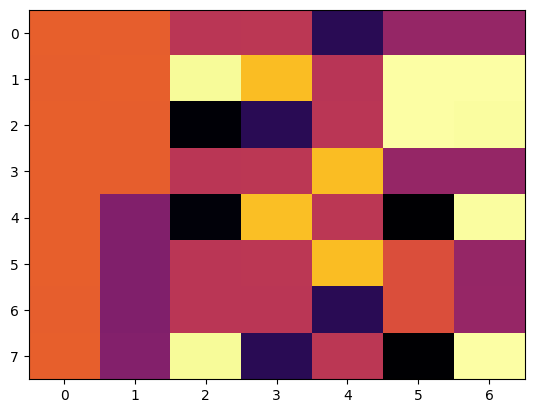

In [11]:
loop.plotIM()

In [19]:
imattheor = np.load("/Users/ellenlee/Documents/pyRTC-IRTF/IRTF/calib/imat/felix_theor_imat_cmds.npy")
m2c = np.load("/Users/ellenlee/Documents/pyRTC-IRTF/IRTF/calib/z2a.20240409b.7modes.npy")

In [23]:
imat = imattheor @ m2c

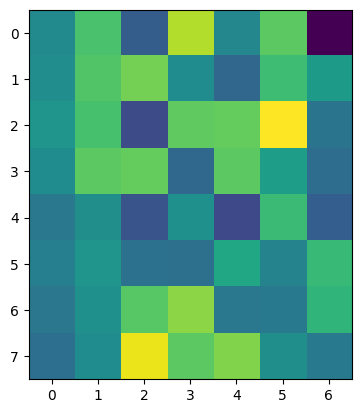

In [20]:
imat = np.load("/Users/ellenlee/Documents/pyRTC-IRTF/IRTF/calib/imat/imat.poke.20251002.c.npy")
plt.figure()
plt.imshow(imat)
plt.show()

In [24]:
imat.shape

(8, 7)

In [12]:
loop.setGain(0.0)

In [15]:
loop.leakyGain = 0.

In [8]:
del(loop)
del(slopes)
del(dm)
del(wfs)
del(tel)

Closing wfsRaw
Closing wfs
Closing wfsInfo
Closing simInjectedSlopes
